# CT phantom preprocessing pipeline test
**Pipeline:** HU conversion → Intesity normalization → Windowing soft tissue → Contrast Enhancement, CLAHE
**Dataset:** FANTOCCIO — series S2010 and S3010 (571/577 slices, 512×512)

---
### Folder structure
```
output/
   ├── preprocessing/
   │   ├── S2010/
   │   │   ├── hu_volume.npy          ← HU volume (step 1)
   │   │   ├── normalized_volume.npy  ← after normalization (step 2)
   │   │   ├── windowed_volume.npy    ← after windowing (step 3)
   │   │   └── spacing.npy            ← voxel spacing (z, y, x) in mm
   │   └── S3010/
   │       ├── hu_volume.npy          ← HU volume (step 1)
   │       ├── normalized_volume.npy  ← after normalization (step 2)
   │       ├── windowed_volume.npy    ← after windowing (step 3)
   │       └── spacing.npy            ← voxel spacing (z, y, x) in mm
   └── figures/
       ├── pipeline_S2010.png
       ├── pipeline_S3010.png
       ├── hu_histogram_S2010.png
       └── hu_histogram_S3010.png
```

In [20]:
# ============================================================
# CELL 0 — Import libraries
# ============================================================

import os
import numpy as np
import pydicom
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import skimage.exposure as exposure

print("Libraries imported.")

Libraries imported.


In [21]:
# ============================================================
# CELL 1 — Create output folder structure
# ============================================================

# Create output directories if they don't exist
OUTPUT_DIRS = [
    "./output/preprocessing_data/test/S2010",
    "./output/preprocessing_data/test/S3010",
    "./output/figures/test",
]
for d in OUTPUT_DIRS:
    os.makedirs(d, exist_ok=True)

# Raw dataset paths
SERIES = {
    "S2010": "./dataset/FANTOCCIO/S72990/S2010",
    "S3010": "./dataset/FANTOCCIO/S72990/S3010",
}

print("Output structure ready.")

Output structure ready.


## Step 1 — Hounsfield Unit (HU) Conversion
Formula: `HU = pixel_value × RescaleSlope + RescaleIntercept`  
The parameters `RescaleSlope` and `RescaleIntercept` are stored in the DICOM metadata of each slice.

Reference HU values relevant to this project:

| Tissue | HU |
|---|---|
| Air | −1000 |
| Adipose / fatty tissue | −100 / −50 |
| Glandular tissue / breast tumour | 20 / 50 |
| Blood / vessels | 50 / 80 |
| Cancellous bone | 200 / 400 |
| Metal (phantom seed / wire) | > 1000 |

In [23]:
# ============================================================
# CELL 2 — STEP 1: Load DICOM volume and convert to HU
# ============================================================

def load_dicom_volume_hu(folder_path, series_name):
    """
    Load all DICOM slices in a series, sort them by SliceLocation
    (anatomical Z position), and convert pixel values to HU.

    Parameters
    ----------
    folder_path : str  — path to the folder containing .dcm files
    series_name : str  — series label used for saving output (e.g. 'S2010')

    Returns
    -------
    hu_volume : np.ndarray (n_slices, rows, cols)  — values in HU
    spacing   : tuple (z_mm, y_mm, x_mm)           — voxel spacing in mm
    """
    # Collect valid DICOM files
    valid_paths = []
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            ds = pydicom.dcmread(fpath, stop_before_pixels=True)
            if hasattr(ds, 'Rows') and hasattr(ds, 'Columns'):
                valid_paths.append(fpath)
        except Exception:
            pass

    if not valid_paths:
        raise FileNotFoundError(f"No valid DICOM files found in {folder_path}")

    # Sort slices by anatomical Z position
    def get_z(fpath):
        ds = pydicom.dcmread(fpath, stop_before_pixels=True)
        if hasattr(ds, 'SliceLocation'):
            return float(ds.SliceLocation)
        elif hasattr(ds, 'InstanceNumber'):
            return float(ds.InstanceNumber)
        return 0.0

    valid_paths.sort(key=get_z)
    print(f"[{series_name}] Slices found and sorted: {len(valid_paths)}")

    # Build 3D volume with HU conversion
    slices_hu = []
    first_ds  = None

    for fpath in valid_paths:
        ds        = pydicom.dcmread(fpath)
        slope     = float(ds.RescaleSlope)     if hasattr(ds, 'RescaleSlope')     else 1.0
        intercept = float(ds.RescaleIntercept) if hasattr(ds, 'RescaleIntercept') else 0.0
        slices_hu.append(ds.pixel_array.astype(np.float32) * slope + intercept)
        if first_ds is None:
            first_ds = ds

    hu_volume = np.stack(slices_hu, axis=0)   # shape: (n_slices, 512, 512)

    # Extract voxel spacing
    z_mm = float(first_ds.SliceThickness) if hasattr(first_ds, 'SliceThickness') else 0.0
    px   = first_ds.PixelSpacing if hasattr(first_ds, 'PixelSpacing') else [1.0, 1.0]
    spacing = (z_mm, float(px[0]), float(px[1]))

    # Save outputs
    out_dir = f"./output/preprocessing_data/test/{series_name}"
    np.save(f"{out_dir}/hu_volume.npy",  hu_volume)
    np.save(f"{out_dir}/spacing.npy",    np.array(spacing))

    print(f"[{series_name}] Volume shape:   {hu_volume.shape}")
    print(f"[{series_name}] HU range:       min={hu_volume.min():.0f}  max={hu_volume.max():.0f}")
    print(f"[{series_name}] Voxel (mm):     Z={spacing[0]:.3f}  Y={spacing[1]:.4f}  X={spacing[2]:.4f}")
    print(f"[{series_name}] Saved to:       {out_dir}/hu_volume.npy")
    print("-" * 60)

    return hu_volume, spacing


# --- RUN on both series ---
print("=== STEP 1: HU Conversion ===")
hu_S2010, spacing_S2010 = load_dicom_volume_hu(SERIES["S2010"], "S2010")
hu_S3010, spacing_S3010 = load_dicom_volume_hu(SERIES["S3010"], "S3010")

=== STEP 1: HU Conversion ===
[S2010] Slices found and sorted: 571
[S2010] Volume shape:   (571, 512, 512)
[S2010] HU range:       min=-1024  max=3071
[S2010] Voxel (mm):     Z=0.670  Y=0.3789  X=0.3789
[S2010] Saved to:       ./output/preprocessing_data/test/S2010/hu_volume.npy
------------------------------------------------------------
[S3010] Slices found and sorted: 577
[S3010] Volume shape:   (577, 512, 512)
[S3010] HU range:       min=-1024  max=3071
[S3010] Voxel (mm):     Z=0.670  Y=0.3340  X=0.3340
[S3010] Saved to:       ./output/preprocessing_data/test/S3010/hu_volume.npy
------------------------------------------------------------


## Step 2 — Intensity Normalization
After HU conversion, values are normalized to the range **[0, 1]** by clipping to the standard clinical range.

- `hu_min = -1024` → reference value for air (physical lower bound of CT);
- `hu_max = 3071` → upper limit of the 12-bit DICOM range;

In [24]:
# ============================================================
# CELL 3 — STEP 2: Intensity normalization to [0, 1]
# ============================================================

def normalize_hu_volume(hu_volume, series_name, hu_min=-1024, hu_max=3071):
    """
    Normalize the HU volume to [0, 1] after clipping to the clinical range.

    Parameters
    ----------
    hu_volume   : np.ndarray (n_slices, rows, cols)
    series_name : str
    hu_min      : float  — minimum HU value to consider (-1024 = air)
    hu_max      : float  — maximum HU value to consider (3071 = 12-bit DICOM limit)

    Returns
    -------
    normalized : np.ndarray (n_slices, rows, cols)  — values in [0, 1]
    """
    clipped    = np.clip(hu_volume, hu_min, hu_max)
    normalized = (clipped - hu_min) / (hu_max - hu_min)

    out_path = f"./output/preprocessing_data/test/{series_name}/normalized_volume.npy"
    np.save(out_path, normalized)

    print(f"[{series_name}] Clip range:    [{hu_min}, {hu_max}] HU")
    print(f"[{series_name}] Output range:  [{normalized.min():.4f}, {normalized.max():.4f}]")
    print(f"[{series_name}] Saved to:      {out_path}")
    print("-" * 60)

    return normalized


# --- RUN ---
print("=== STEP 2: Normalization ===")
norm_S2010 = normalize_hu_volume(hu_S2010, "S2010")
norm_S3010 = normalize_hu_volume(hu_S3010, "S3010")

=== STEP 2: Normalization ===
[S2010] Clip range:    [-1024, 3071] HU
[S2010] Output range:  [0.0000, 1.0000]
[S2010] Saved to:      ./output/preprocessing_data/test/S2010/normalized_volume.npy
------------------------------------------------------------
[S3010] Clip range:    [-1024, 3071] HU
[S3010] Output range:  [0.0000, 1.0000]
[S3010] Saved to:      ./output/preprocessing_data/test/S3010/normalized_volume.npy
------------------------------------------------------------


## Step 3 — Windowing (soft tissue window)
Windowing selects the HU range of interest for the target tissue. It is applied on the **original HU volume** (not on the normalized one).

**Chosen parameters — soft tissue window for breast tissue:**
- `Window Center (WC) = 50 HU` → centre of the range of interest
- `Window Width  (WW) = 400 HU` → width of the range
- Resulting range: `[-150, +250] HU`

**Justification from the HU scale:**  
Adipose tissue (−100 HU) and glandular/tumour tissue (20–50 HU) both fall within the selected range, while bone and metal (> 400 HU) are excluded.

In [25]:
# ============================================================
# CELL 4 — STEP 3: Windowing
# Applied on the ORIGINAL HU volume
# ============================================================

def apply_windowing(hu_volume, series_name, window_center=50, window_width=400):
    """
    Apply CT windowing for soft tissue / breast imaging.

    Parameters
    ----------
    hu_volume      : np.ndarray (n_slices, rows, cols) — ORIGINAL HU volume
    series_name    : str
    window_center  : int  — WC in HU (default 50 = soft tissue)
    window_width   : int  — WW in HU (default 400 = soft tissue)

    Returns
    -------
    windowed : np.ndarray (n_slices, rows, cols) — values in [0, 1]
    """
    lower    = window_center - window_width / 2   # -150 HU
    upper    = window_center + window_width / 2   # +250 HU

    windowed = np.clip(hu_volume, lower, upper)
    windowed = (windowed - lower) / (upper - lower)  # normalize to [0, 1]

    out_path = f"./output/preprocessing_data/test/{series_name}/windowed_volume.npy"
    np.save(out_path, windowed)

    print(f"[{series_name}] WC={window_center} HU  |  WW={window_width} HU")
    print(f"[{series_name}] HU range used:  [{lower:.0f}, {upper:.0f}]")
    print(f"[{series_name}] Output range:   [{windowed.min():.3f}, {windowed.max():.3f}]")
    print(f"[{series_name}] Saved to:       {out_path}")
    print("-" * 60)

    return windowed


# --- RUN on the original HU volume (not on norm_*) ---
print("=== STEP 3: Windowing ===")
windowed_S2010 = apply_windowing(hu_S2010, "S2010", window_center=50, window_width=400)
windowed_S3010 = apply_windowing(hu_S3010, "S3010", window_center=50, window_width=400)

=== STEP 3: Windowing ===
[S2010] WC=50 HU  |  WW=400 HU
[S2010] HU range used:  [-150, 250]
[S2010] Output range:   [0.000, 1.000]
[S2010] Saved to:       ./output/preprocessing_data/test/S2010/windowed_volume.npy
------------------------------------------------------------
[S3010] WC=50 HU  |  WW=400 HU
[S3010] HU range used:  [-150, 250]
[S3010] Output range:   [0.000, 1.000]
[S3010] Saved to:       ./output/preprocessing_data/test/S3010/windowed_volume.npy
------------------------------------------------------------


## Step 4 (test) — Contrast Enhancement (CLAHE)
CLAHE (Contrast Limited Adaptive Histogram Equalization) improves local contrast without amplifying noise — useful for enhancing lesion boundaries before segmentation.

It is applied **slice by slice** on the windowed volume.

In [26]:
# ============================================================
# CELL 5 — STEP 4 (test): CLAHE contrast enhancement
# ============================================================

def apply_clahe(windowed_volume, series_name, clip_limit=0.02, nbins=256):
    """
    Apply CLAHE slice by slice on the windowed volume.

    Parameters
    ----------
    windowed_volume : np.ndarray (n_slices, rows, cols) — values in [0, 1]
    series_name     : str
    clip_limit      : float — contrast amplification limit (0.02 = conservative)
    nbins           : int   — number of histogram bins

    Returns
    -------
    clahe_volume : np.ndarray (n_slices, rows, cols) — values in [0, 1]
    """

    clahe_volume = np.zeros_like(windowed_volume)
    n = windowed_volume.shape[0]

    for i in range(n):
        clahe_volume[i] = exposure.equalize_adapthist(
            windowed_volume[i],
            clip_limit=clip_limit,
            nbins=nbins
        )
        if (i + 1) % 100 == 0:
            print(f"  [{series_name}] Slice {i+1}/{n} processed...")

    out_path = f"./output/preprocessing_data/test/{series_name}/clahe_volume.npy"
    np.save(out_path, clahe_volume)

    print(f"[{series_name}] CLAHE complete — clip_limit={clip_limit}")
    print(f"[{series_name}] Saved to: {out_path}")
    return clahe_volume


# --- RUN (comment out if you want to skip) ---
print("=== STEP 4 (test): CLAHE ===")
clahe_S2010 = apply_clahe(windowed_S2010, "S2010")
clahe_S3010 = apply_clahe(windowed_S3010, "S3010")

=== STEP 4 (test): CLAHE ===
  [S2010] Slice 100/571 processed...
  [S2010] Slice 200/571 processed...
  [S2010] Slice 300/571 processed...
  [S2010] Slice 400/571 processed...
  [S2010] Slice 500/571 processed...
[S2010] CLAHE complete — clip_limit=0.02
[S2010] Saved to: ./output/preprocessing_data/test/S2010/clahe_volume.npy
  [S3010] Slice 100/577 processed...
  [S3010] Slice 200/577 processed...
  [S3010] Slice 300/577 processed...
  [S3010] Slice 400/577 processed...
  [S3010] Slice 500/577 processed...
[S3010] CLAHE complete — clip_limit=0.02
[S3010] Saved to: ./output/preprocessing_data/test/S3010/clahe_volume.npy


---
## Visualization — Full pipeline comparison
Visual comparison of all 4 stages across 3 representative slices (25% / 50% / 75% of the volume).

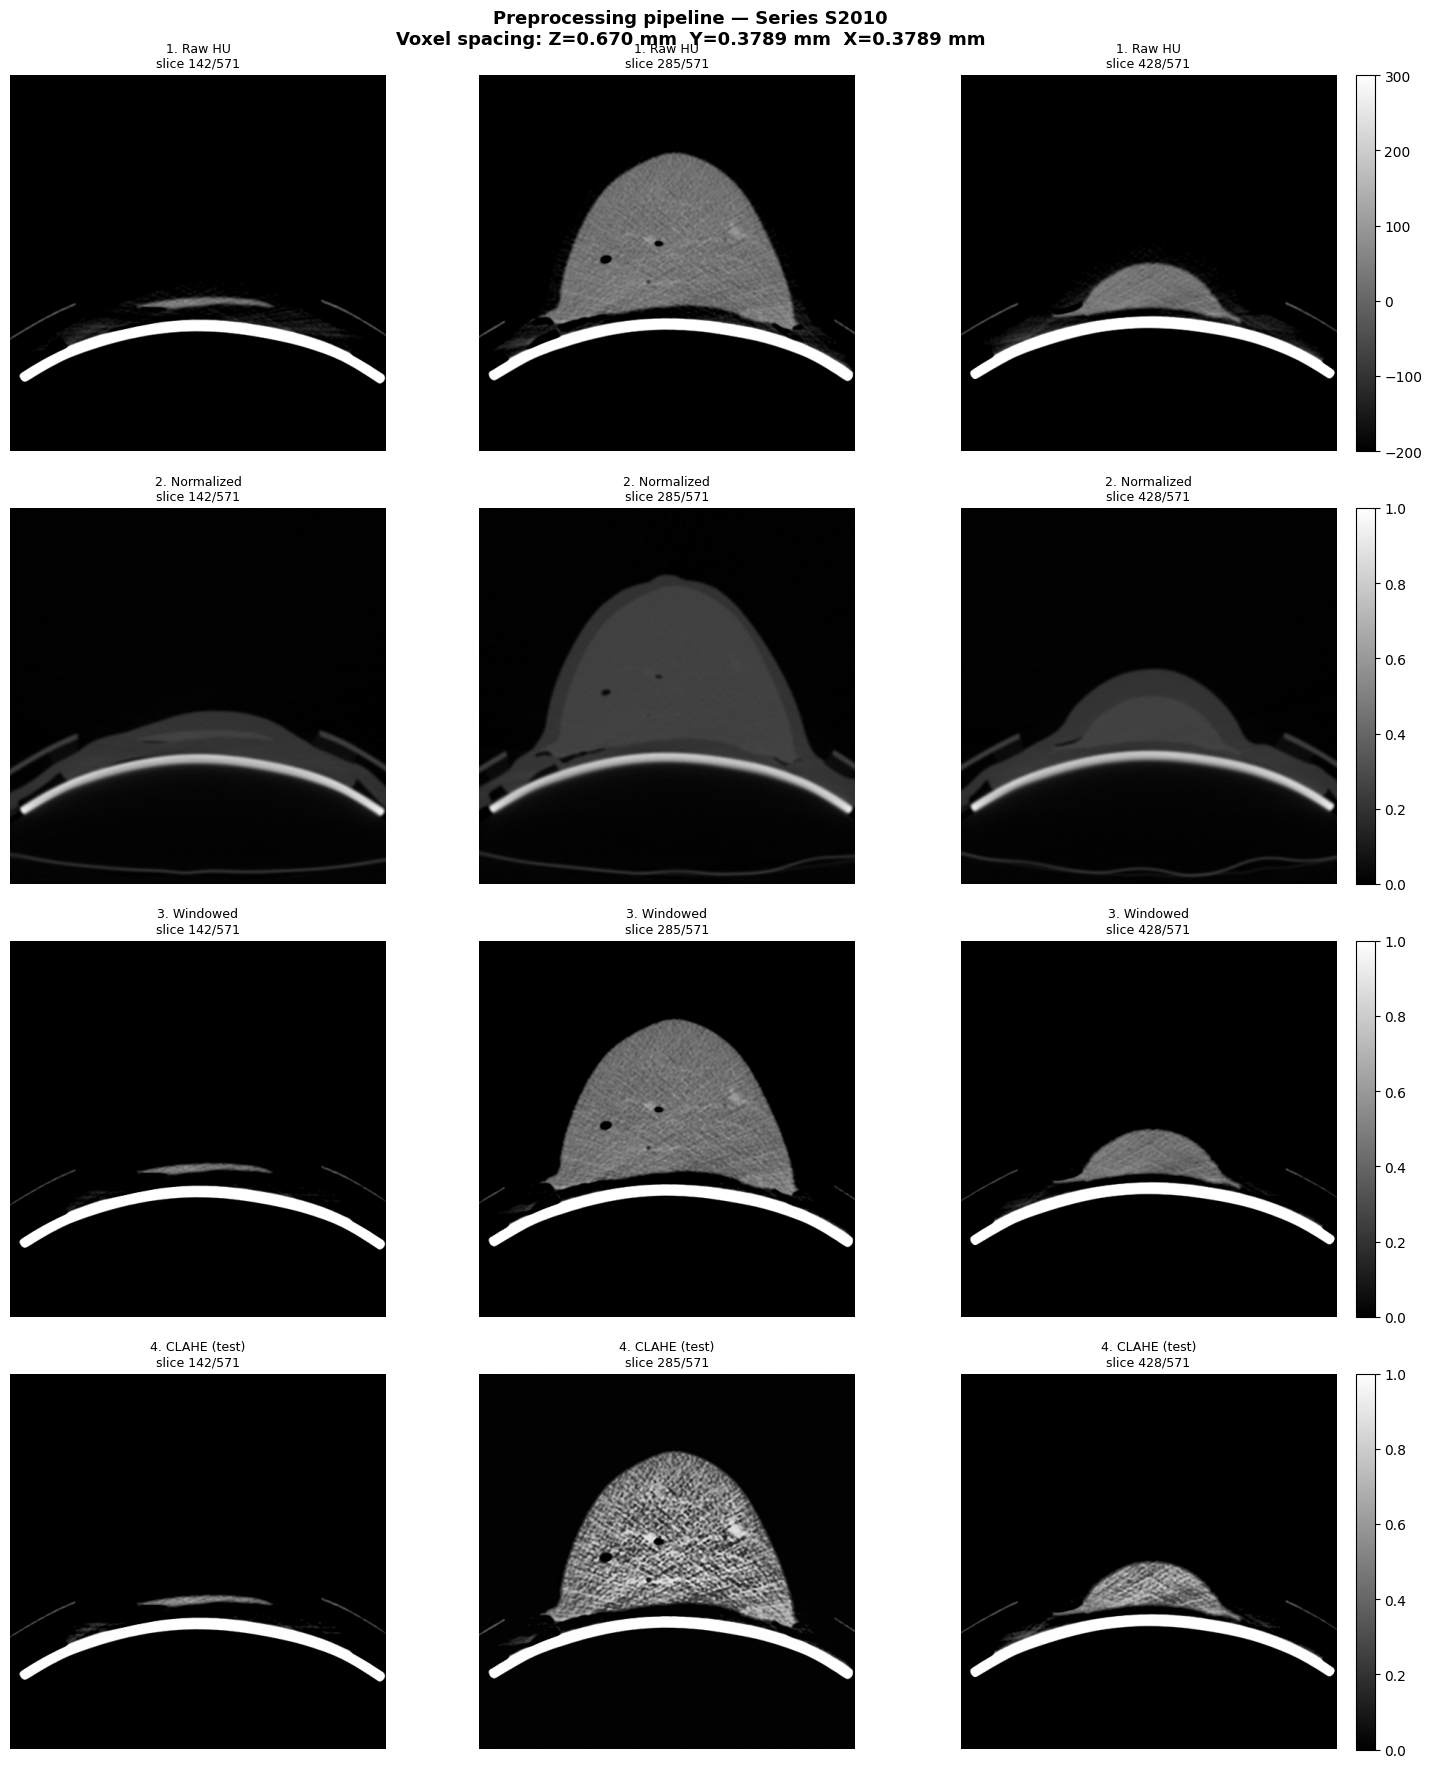

Figure saved to: ./output/figures/test/pipeline_S2010.png


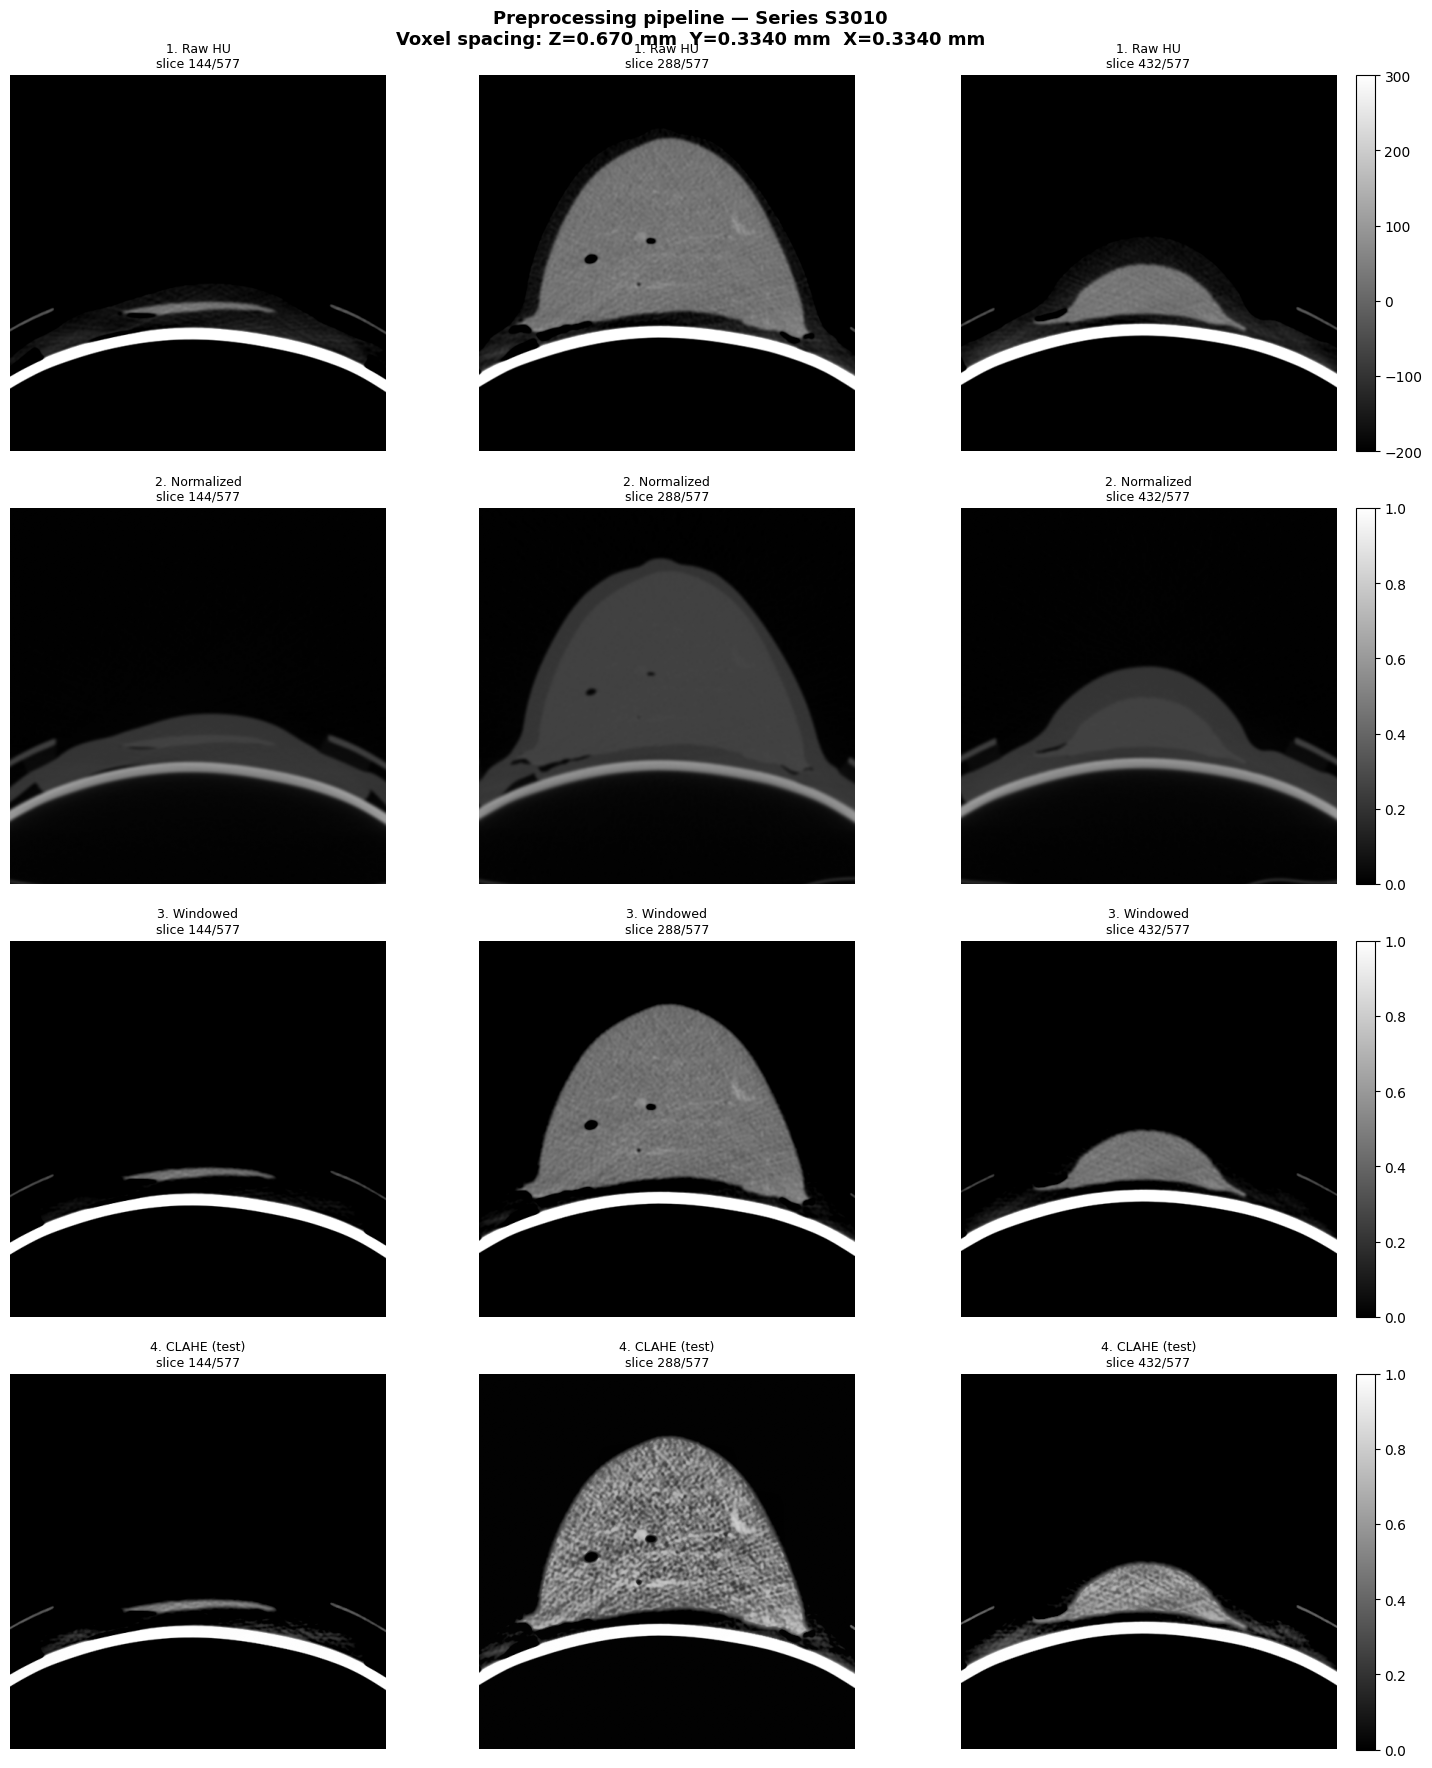

Figure saved to: ./output/figures/test/pipeline_S3010.png


In [27]:
# ============================================================
# CELL 6 — Full pipeline visualization (4 rows x 3 slices)
# ============================================================

def visualize_full_pipeline(hu_vol, norm_vol, wind_vol, clahe_vol,
                             series_name, spacing):
    """
    Generate a figure with 4 rows (raw HU / normalized / windowed / CLAHE)
    x 3 columns (slices at 25%, 50%, 75% of the volume).
    Saved to output/figures/pipeline_{series_name}.png
    """
    n    = hu_vol.shape[0]
    idxs = [n // 4, n // 2, 3 * n // 4]

    rows_data = [
        (hu_vol,    "1. Raw HU",           dict(vmin=-200, vmax=300)),
        (norm_vol,  "2. Normalized",       dict(vmin=0, vmax=1)),
        (wind_vol,  "3. Windowed",         dict(vmin=0, vmax=1)),
        (clahe_vol, "4. CLAHE (test)", dict(vmin=0, vmax=1)),
    ]

    fig, axes = plt.subplots(4, 3, figsize=(15, 18))
    fig.suptitle(
        f"Preprocessing pipeline — Series {series_name}\n"
        f"Voxel spacing: Z={spacing[0]:.3f} mm  Y={spacing[1]:.4f} mm  X={spacing[2]:.4f} mm",
        fontsize=13, fontweight='bold'
    )

    for row_idx, (vol, row_label, imshow_kwargs) in enumerate(rows_data):
        for col_idx, slice_idx in enumerate(idxs):
            ax = axes[row_idx, col_idx]
            im = ax.imshow(vol[slice_idx], cmap='gray', **imshow_kwargs)
            ax.set_title(f"{row_label}\nslice {slice_idx}/{n}", fontsize=9)
            ax.axis('off')
            if col_idx == 2:  # colorbar on last column only
                plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    out_path = f"./output/figures/test/pipeline_{series_name}.png"
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Figure saved to: {out_path}")

# --- RUN ---
visualize_full_pipeline(hu_S2010, norm_S2010, windowed_S2010, clahe_S2010, "S2010", spacing_S2010)
visualize_full_pipeline(hu_S3010, norm_S3010, windowed_S3010, clahe_S3010, "S3010", spacing_S3010)

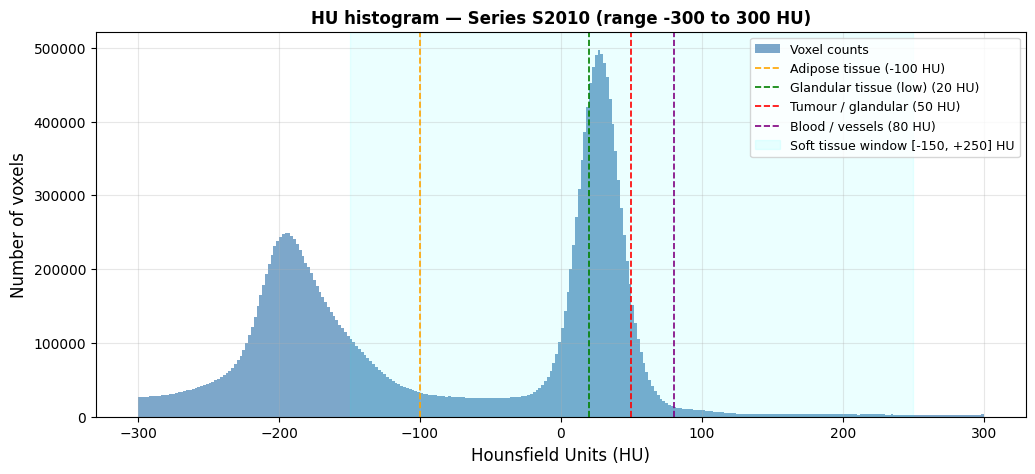

Histogram saved to: ./output/figures/test/hu_histogram_S2010.png


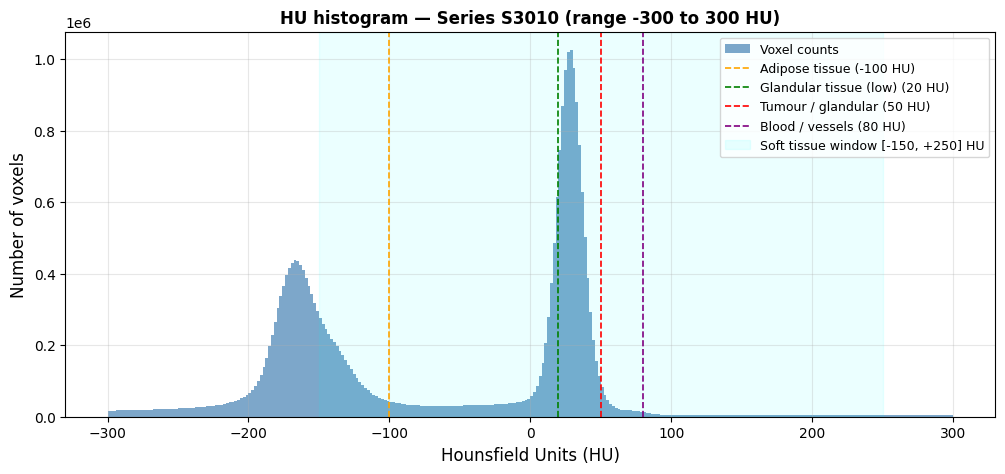

Histogram saved to: ./output/figures/test/hu_histogram_S3010.png


In [28]:
# ============================================================
# CELL 7 — HU histogram (useful for threshold justification)
# Excludes extreme values (air and metal) to highlight the
# soft tissue distribution.
# ============================================================

def plot_hu_histogram(hu_volume, series_name, hu_range=(-300, 300)):
    """
    Plot the HU histogram of the volume (soft tissue range) with
    annotations for tissue reference values.
    Useful for justifying the choice of segmentation threshold.
    """
    flat         = hu_volume.flatten()
    flat_cropped = flat[(flat >= hu_range[0]) & (flat <= hu_range[1])]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.hist(flat_cropped, bins=300, color='steelblue', alpha=0.7, label='Voxel counts')

    # Tissue reference lines
    ref_lines = [
        (-100, 'Adipose tissue',         'orange'),
        (  20, 'Glandular tissue (low)', 'green'),
        (  50, 'Tumour / glandular',     'red'),
        (  80, 'Blood / vessels',        'purple'),
    ]
    for hu_val, label, color in ref_lines:
        ax.axvline(hu_val, color=color, linestyle='--', linewidth=1.2,
                   label=f"{label} ({hu_val} HU)")

    # Highlight soft tissue window (WC=50, WW=400)
    ax.axvspan(-150, 250, alpha=0.08, color='cyan',
               label='Soft tissue window [-150, +250] HU')

    ax.set_xlabel("Hounsfield Units (HU)", fontsize=12)
    ax.set_ylabel("Number of voxels", fontsize=12)
    ax.set_title(
        f"HU histogram — Series {series_name} (range {hu_range[0]} to {hu_range[1]} HU)",
        fontsize=12, fontweight='bold'
    )
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    out_path = f"./output/figures/test/hu_histogram_{series_name}.png"
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Histogram saved to: {out_path}")


# --- RUN ---
plot_hu_histogram(hu_S2010, "S2010")
plot_hu_histogram(hu_S3010, "S3010")